In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('study_hours_grades_lab.csv')

In [4]:
df.info

<bound method DataFrame.info of      StudyHours  Grade
0            15  100.0
1            14   93.3
2            15  100.0
3             3   46.9
4            13   90.5
..          ...    ...
115          10   80.4
116           3   64.8
117           4   50.2
118          12  100.0
119           4   68.0

[120 rows x 2 columns]>

In [5]:
df.values

array([[ 15. , 100. ],
       [ 14. ,  93.3],
       [ 15. , 100. ],
       [  3. ,  46.9],
       [ 13. ,  90.5],
       [  3. ,  54.2],
       [  7. ,  63.7],
       [  2. ,  50.2],
       [  4. ,  43.6],
       [ 11. ,  90.9],
       [ 12. ,  83.1],
       [ 10. ,  88.5],
       [  7. ,  70.4],
       [  2. ,  51.7],
       [  1. ,  51.9],
       [  2. ,  49.8],
       [ 15. , 100. ],
       [ 10. ,  78.2],
       [  1. ,  48.4],
       [ 15. , 100. ],
       [  1. ,  33.8],
       [ 10. ,  83.6],
       [  4. ,  66.3],
       [ 15. ,  94.8],
       [ 14. , 100. ],
       [  5. ,  64.1],
       [  1. ,  40.6],
       [  1. ,  46.1],
       [  5. ,  72. ],
       [  2. ,  43.3],
       [  8. ,  85.7],
       [  4. ,  56.6],
       [  3. ,  54.8],
       [  5. ,  60.3],
       [  8. ,  82. ],
       [  3. ,  52. ],
       [  5. ,  53. ],
       [  9. ,  81.8],
       [ 14. , 100. ],
       [  1. ,  40.2],
       [  8. ,  93.4],
       [ 10. ,  93. ],
       [  4. ,  61.6],
       [ 13

In [7]:
df.isnull()

,StudyHours,Grade
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
115,False,False
116,False,False
117,False,False
118,False,False


In [9]:
df.isnull().sum()

StudyHours    0
Grade         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(13)

In [12]:
df.drop_duplicates()

,StudyHours,Grade
0,15,100.0
1,14,93.3
3,3,46.9
4,13,90.5
5,3,54.2
...,...,...
114,8,73.7
115,10,80.4
116,3,64.8
117,4,50.2


In [13]:
df.duplicated().sum()

np.int64(13)

In [16]:
x = df[['StudyHours']]
y = df[['Grade']]

In [17]:
import seaborn as sns

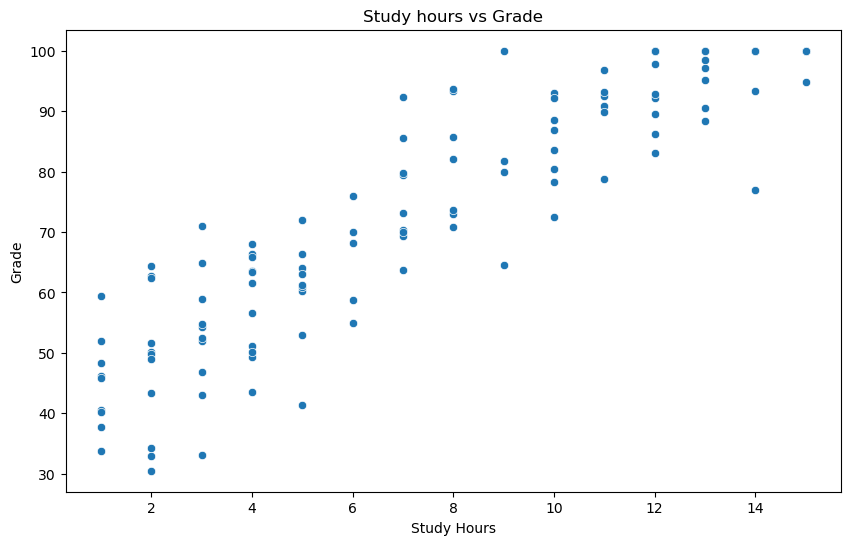

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='StudyHours', y='Grade', data=df)
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.title('Study hours vs Grade')
plt.show()

In [30]:
X = df[['StudyHours']]
y = df[['Grade']]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 30)

In [32]:
print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 84
Testing size: 36


In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [58]:
slope = float(model.coef_[0])
intercept = float(model.intercept_)

/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_15786/3871659135.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  slope = float(model.coef_[0])
/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_15786/3871659135.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  intercept = float(model.intercept_)


In [59]:
print(slope)
print(intercept)

4.216910495486574
41.33826225982624


In [60]:
print(type(intercept))
print(type(slope))

<class 'float'>
<class 'float'>


In [61]:
print("Regression equation: Grade = {:.2f} + {:.2f} * StudyHours".format(intercept, slope))

Regression equation: Grade = 41.34 + 4.22 * StudyHours


In [63]:
hours = pd.DataFrame({'StudyHours': [5, 10, 15]})
predictions = model.predict(hours)

In [65]:
hours = [5, 10, 15]
predictions = model.predict(pd.DataFrame({'StudyHours': hours}))

for i, h in enumerate(hours):
    print(f"Predicted grade for {h} hours of study = {predictions[i]}")

Predicted grade for 5 hours of study = [62.42281474]
Predicted grade for 10 hours of study = [83.50736721]
Predicted grade for 15 hours of study = [104.59191969]


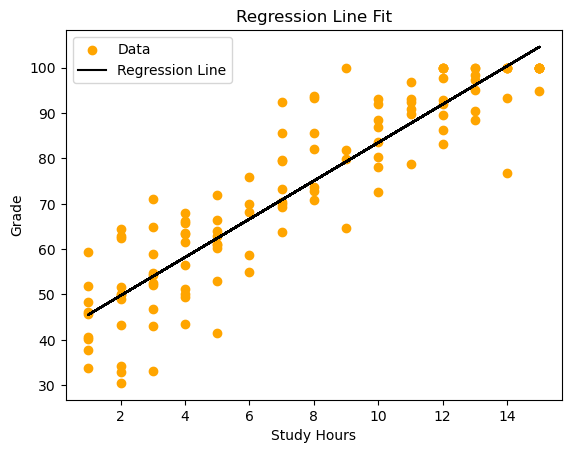

In [67]:
plt.scatter(df["StudyHours"], df["Grade"], color="orange", label="Data")
plt.plot(df["StudyHours"], model.predict(df[["StudyHours"]]), color="black", label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Grade")
plt.title("Regression Line Fit")
plt.legend()
plt.show()

In [69]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8035092056961709


In [70]:
if slope > 0:
    print("Conclusion: Yes, studying more hours generally leads to higher grades.")
else:
    print("Conclusion: No, study hours do not strongly predict grades.")

Conclusion: Yes, studying more hours generally leads to higher grades.
